# XGBoost Surrogate Model for Sensitivity Analysis on AlphaPEM Polarization Curves

In this notebook, our goal is to train a surrogate model using XGBoost to approximate the polarization curves (voltage vs. current density) generated by the AlphaPEM model. Each simulation run depends on 13 input parameters (operating conditions and undetermined physical parameters), and the output is a voltage vector evaluated at different current densities.

The goal is to obtain a fast and accurate surrogate that allows us to perform **global sensitivity analysis**—both via **Shapley values** and **Sobol indices**—without incurring the heavy computational cost of evaluating the full AlphaPEM model.

Our data contains some runs labeled as:
- `"valid"`: the resulting polarization curve satisfies physical and empirical validity checks,
- `"invalid"`: the simulation ran, but the resulting curve shows unphysical behavior (e.g., out-of-range voltages),
- `"missing"`: the simulation failed to complete (very rare, ~0.01%).

In this notebook, I will:
- Filter the dataset to only include valid samples for training and evaluation of the surrogate.
- Use the 13 input parameters (and additionally, the current density as an input feature) to predict the voltage output.
- Evaluate model performance on held-out valid samples.
- Once the model is validated, we may explore how well it generalizes to the invalid/missing samples (e.g., does it flag them as clearly distinct?).
- Perform sensitivity analysis on the trained surrogate using Shapley values and Sobol indices to obtain a ranked list of feature importances.

This ranking will guide the selection of a reduced, most influential parameter set to be used in the development of a more interpretable analytical surrogate model.


In [2]:
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, max_error
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import pandas as pd
import numpy as np
import joblib
import seaborn as sns

c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import sys
import os
import pandas as pd
sys.path.append("../external/AlphaPEM")

# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters
from src.validity.validity_criteria import validate_polarization_curves

In [4]:
csv_path = r"../sampling_test/validated_final_df.pkl"
data = pd.read_pickle(csv_path)
print("There are", len(data), "polarization curves available.")
print(data.columns)
data.head()

There are 28672 polarization curves available.
Index(['Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl', 'tau', 'epsilon_mc',
       'epsilon_c', 'e', 'Re',
       ...
       'Ucell_22', 'Ucell_23', 'Ucell_24', 'Ucell_25', 'Ucell_26', 'Ucell_27',
       'Ucell_28', 'Ucell_29', 'Ucell_30', 'classification'],
      dtype='object', length=111)


,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,...,Ucell_22,Ucell_23,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30,classification
0,345.931298,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.729581,0.720127,0.710685,0.701266,0.691858,0.682437,0.672987,0.663492,0.653933,valid
1,350.820492,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.714529,0.707308,0.699520,0.691411,0.682963,0.674201,0.665215,0.656067,0.646718,valid
2,345.931298,201919.596742,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.674925,0.678619,0.672719,0.664526,0.658328,0.651771,0.644673,0.636798,0.628506,valid
3,345.931298,268431.866782,1.789658,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.716600,0.706744,0.696881,0.686989,0.677044,0.667028,0.656922,0.646707,0.636362,valid
4,345.931298,268431.866782,2.632068,0.145910,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.729362,0.719902,0.710475,0.701074,0.691673,0.682255,0.672806,0.663305,0.653740,valid


In [7]:
data.columns

Index(['Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl', 'tau', 'epsilon_mc',
       'epsilon_c', 'e', 'Re',
       ...
       'Ucell_22', 'Ucell_23', 'Ucell_24', 'Ucell_25', 'Ucell_26', 'Ucell_27',
       'Ucell_28', 'Ucell_29', 'Ucell_30', 'classification'],
      dtype='object', length=111)

In [10]:
# Define feature sets
operating_conditions = [
    "Tfc", "Pa_des", "Pc_des", "Sa", "Sc", "Phi_a_des", "Phi_c_des"
]
undetermined_params = [
    "epsilon_gdl", "tau", "epsilon_mc", "epsilon_c", "e", "Re", "i0_c_ref",
    "kappa_co", "kappa_c", "a_slim", "b_slim", "a_switch"
]

ifc_columns = [col for col in data.columns if col.startswith("ifc_")]
ucell_columns = [col for col in data.columns if col.startswith("Ucell_")]

PARAMETER_RANGES = {
    'Tfc': [333, 363],
    'Pa_des': [130000.0, 300000.0],
    'Sc': [1.1, 3.0],
    'Phi_c_des': [0.1, 0.7],
    'epsilon_gdl': [0.55, 0.8],
    'tau': [1.0, 4.0],
    'epsilon_mc': [0.15, 0.4],
    'epsilon_c': [0.15, 0.3],
    'e': [3, 4, 5],
    'Re': [5e-07, 5e-06],
    'i0_c_ref': [0.001, 80],
    'kappa_co': [15, 40],
    'kappa_c': [0, 2.5],
}
INPUT_COLUMNS = list(PARAMETER_RANGES.keys())

FIXED_PARAMETERS = list(set(operating_conditions + undetermined_params) - set(INPUT_COLUMNS))

In [6]:
classification_summary = (
    data["classification"]
    .value_counts()
    .rename_axis("classification")
    .reset_index(name="count")
)

total = len(data)
classification_summary["percentage (%)"] = (classification_summary["count"] / total * 100).round(2)
classification_summary

,classification,count,percentage (%)
0,valid,27708,96.64
1,invalid,942,3.29
2,invalid_no_output,22,0.08


### Exclusion of invalid polarization curves from training

For training the surrogate model, I include only configurations labeled as `"valid"` — that is, those producing physically plausible polarization curves. we exclude `"invalid"` and `"invalid_no_output"` samples from both training and evaluation.

This is reasonable because:
- Invalid curves often result from unphysical or extreme parameter combinations that lead to simulation artifacts (e.g., negative voltages, out-of-range behavior).
- Including them would force the model to learn from noisy or contradictory targets, reducing its ability to capture the true structure of the valid response surface.
- Our goal is to build a surrogate that accurately mimics AlphaPEM in its "physically meaningful operating regime".

After model evaluation, we may use the trained surrogate to explore how it behaves on invalid or borderline configurations, but these are deliberately kept out of the training process.


In [12]:
# Keep only valid polarization curves
valid_data = data[data["classification"] == "valid"].copy().drop(columns = FIXED_PARAMETERS)
valid_data["config_id"] = valid_data.index  # preserve original index as column
print(f"Retained {len(valid_data)} valid samples out of {len(data)} total.")

Retained 27708 valid samples out of 28672 total.


### About input representation: Including current density

To model the polarization curve with a scalar-output surrogate, we will include **current density as an input feature**, so that the model learns to predict the voltage at any given current for a given configuration. This allows us to frame the task as a standard (scalar!) regression problem:

> (13 input parameters + current density) → voltage

However, since each full polarization curve corresponds to a unique experimental configuration, I ensure that the training and test splits are done at the configuration level. That is, all 31 current-voltage points from a given configuration are assigned either to the training set or the test set, but never split across both. This avoids information leakage* and gives a more realistic estimate of generalization performance.

(*) If we randomly split rows of this reshaped dataset, then:
- Some current-voltage pairs from a given configuration could end up in the training set
- Others (from the same configuration) could end up in the test set

This creates data leakage, because the model sees part of the "answer" during training. As a result, it can simply interpolate over current density and appear to generalize well, but this is misleading as, in real life, we will ask the model to predict a full polarization curve.

In [ ]:
# Melt current and voltage columns
melted_ifc = valid_data[["config_id"] + ifc_columns].melt(
    id_vars=["config_id"], var_name="ifc_label", value_name="ifc"
)

melted_ucell = valid_data[ucell_columns].melt(
    var_name="ucell_label", value_name="ucell"
)

# Combine into long format
long_data = pd.concat([melted_ifc, melted_ucell], axis=1)

# Filter to ensure alignment of indices
aligned = long_data["ifc_label"].str.split("_").str[1] == long_data["ucell_label"].str.split("_").str[1]
long_data = long_data[aligned].copy()

# Join static parameters
param_data = valid_data[["config_id"] + INPUT_COLUMNS]
long_data = long_data.merge(param_data, on="config_id", how="left")
long_data = long_data.drop(columns=["ifc_label", "ucell_label"])

print(len(long_data))
long_data.head()

858948


,config_id,ifc,ucell,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c
0,0,0.000821,1.033675,345.931298,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271
1,1,0.000814,1.021434,350.820492,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271
2,2,0.000816,1.036704,345.931298,201919.596742,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271
3,3,0.000813,1.022000,345.931298,268431.866782,1.789658,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271
4,4,0.000821,1.033369,345.931298,268431.866782,2.632068,0.145910,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271


In [16]:
# Split configurations at config level (no leakage)
unique_configs = long_data["config_id"].unique()
train_configs, test_configs = train_test_split(unique_configs, test_size=0.2, random_state=42)

# Apply mask
train_df = long_data[long_data["config_id"].isin(train_configs)]
test_df = long_data[long_data["config_id"].isin(test_configs)]

# Final features
input_features = INPUT_COLUMNS + ["ifc"]

X_train = train_df[input_features]
y_train = train_df["ucell"]

X_test = test_df[input_features]
y_test = test_df["ucell"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (687146, 14)
X_test shape: (171802, 14)
y_train shape: (687146,)
y_test shape: (171802,)


In [ ]:
# Normalize current density
scaler = MinMaxScaler()
long_data["ifc_scaled"] = scaler.fit_transform(long_data[["ifc"]])
input_features = [col if col != "ifc" else "ifc_scaled" for col in input_features]

# Prepare input/output
X = long_data[input_features]
y = long_data["ucell"]
groups = long_data["config_id"]

# Define model and param grid
model = xgb.XGBRegressor(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [6, 8],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

gkf = GroupKFold(n_splits=5)

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=gkf.split(X, y, groups),
    scoring="neg_mean_absolute_error",
    verbose=1,
    n_jobs=-1
)

# Fit grid search
grid.fit(X, y)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


In [60]:
print("Best params:", grid.best_params_)
print("Best MAE (CV):", -grid.best_score_)

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 500, 'subsample': 0.8}
Best MAE (CV): 0.07789451243495521


In [32]:
# Train final model with best params on full data
final_model = xgb.XGBRegressor(**grid.best_params_, random_state=42, n_jobs=-1)
final_model.fit(X, y)

joblib.dump(final_model, "xgboost_best_model.pkl")
print("Saved best model as 'xgboost_best_model.pkl'") 

Saved best model as 'xgboost_best_model.pkl'


In [ ]:
# --- Prepare input and output ---
X = long_data[input_features]  # already has 'ifc_scaled' and no constant cols
y = long_data["ucell"]
groups = long_data["config_id"]

# --- Best hyperparameters from grid search ---
model_best_hp = xgb.XGBRegressor(
    **grid.best_params_,
    random_state=42,
    n_jobs=-1
)

# --- Cross-validation setup ---
gkf = GroupKFold(n_splits=5)
fold = 1

mae_scores = []
r2_scores = []
rmse_scores = []
maxerr_scores = []

print("Evaluating final model_best_hp with cross-validation:\n")

for train_idx, test_idx in gkf.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model_best_hp.fit(X_train, y_train)
    y_pred = model_best_hp.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)
    maxerr = max_error(y_test, y_pred)

    print(f"Fold {fold}: MAE={mae:.4f}, R²={r2:.4f}, RMSE={rmse:.4f}, MaxErr={maxerr:.4f}")

    mae_scores.append(mae)
    r2_scores.append(r2)
    rmse_scores.append(rmse)
    maxerr_scores.append(maxerr)
    fold += 1

# --- Summary of CV metrics ---
print("\nCross-Validation Summary for model_best_hp:")
print(f"Mean MAE:   {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"Mean R²:    {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"Mean RMSE:  {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"Mean MaxErr:{np.mean(maxerr_scores):.4f} ± {np.std(maxerr_scores):.4f}")

Evaluating final model_best_hp with cross-validation:

Fold 1: MAE=0.0766, R²=0.7180, RMSE=0.0425, MaxErr=5.5673
Fold 2: MAE=0.0768, R²=0.7030, RMSE=0.0466, MaxErr=6.6576
Fold 3: MAE=0.0800, R²=0.6905, RMSE=0.0503, MaxErr=5.6828
Fold 4: MAE=0.0797, R²=0.6809, RMSE=0.0531, MaxErr=5.3368
Fold 5: MAE=0.0774, R²=0.7049, RMSE=0.0482, MaxErr=5.2040

Cross-Validation Summary for model_best_hp:
Mean MAE:   0.0781 ± 0.0015
Mean R²:    0.6995 ± 0.0127
Mean RMSE:  0.0481 ± 0.0035
Mean MaxErr:5.6897 ± 0.5123


### Visualizing Predicted vs True Polarization Curves (with Metrics)

To better understand where the surrogate performs well or poorly, we reconstruct full polarization curves and compare the predicted vs. true voltages.

Each plot includes:
- The true curve from AlphaPEM (blue)
- The predicted curve from the surrogate (orange)
- The MAE and R² values printed above the plot to quantify fit quality

In [69]:
# Add predictions to wide format
def get_predicted_curve(config_id):
    subset = long_data[long_data["config_id"] == config_id].copy()
    subset = subset.sort_values("ifc")
    voltages = subset["y_pred"].values
    return pd.Series(voltages, index=[f"Ucell_pred_{i}" for i in range(len(voltages))])


# Plotting function
def plot_true_vs_predicted(row, print_legend=True):
    ucell_cols = [col for col in row.index if col.startswith("Ucell_") and not col.startswith("Ucell_pred_")]
    ucell_pred_cols = [col for col in row.index if col.startswith("Ucell_pred_")]
    ifc_cols = [col for col in row.index if col.startswith("ifc_")]

    voltages_true = row[ucell_cols].values.astype(float)
    voltages_pred = row[ucell_pred_cols].values.astype(float)
    current_densities = row[ifc_cols].values.astype(float)

    # Compute metrics
    mae = mean_absolute_error(voltages_true, voltages_pred)
    r2 = r2_score(voltages_true, voltages_pred)

    plt.figure(figsize=(8, 5))
    plt.plot(current_densities, voltages_true, marker='o', label="True", color="blue")
    plt.plot(current_densities, voltages_pred, marker='x', label="Predicted", color="orange")
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.title(f"Polarization Curve (config id={row['config_id']}) \n MAE: {mae:.4f} V,  R-squared: {r2:.4f}")
    # plt.suptitle(f"MAE: {mae:.4f} V | R²: {r2:.4f}", fontsize=10, y=0.91)
    plt.xlabel(r"Current density $i_{fc}$ (A.cm$^{-2}$)")
    plt.ylabel(r"Cell voltage $U_{cell}$ (V)")
    plt.grid(True)
    if print_legend:
        plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Predict on full dataset
long_data["y_pred"] = final_model.predict(X)

# Compute per-curve MAE
per_config_mae = long_data.groupby("config_id").apply(
    lambda df: mean_absolute_error(df["ucell"], df["y_pred"])
).reset_index(name="mae")

# Get best and worst IDs
ls_best_ids = per_config_mae.sort_values("mae").head(5)["config_id"]
ls_worst_ids = per_config_mae.sort_values("mae", ascending = False).head(5)["config_id"]

# Get original (wide) data
original_df = valid_data.copy()
original_df["config_id"] = original_df.index
original_df = original_df.join(original_df["config_id"].apply(get_predicted_curve))

C:\Users\User\AppData\Local\Temp\ipykernel_18768\690390159.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_config_mae = long_data.groupby("config_id").apply(


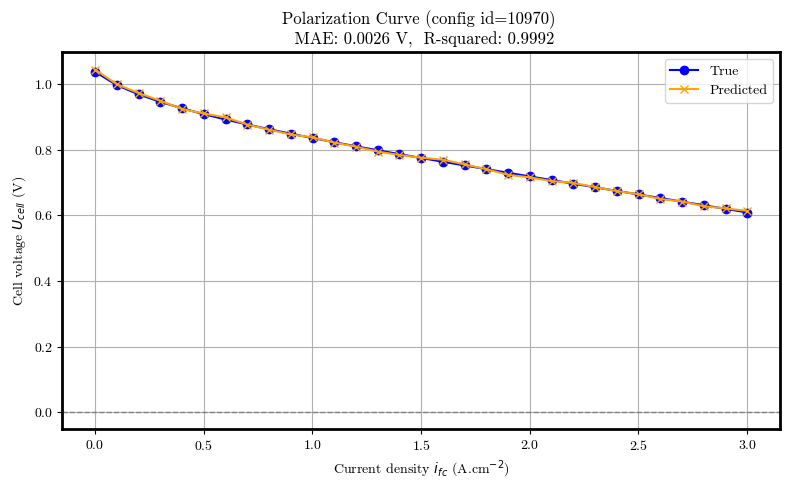

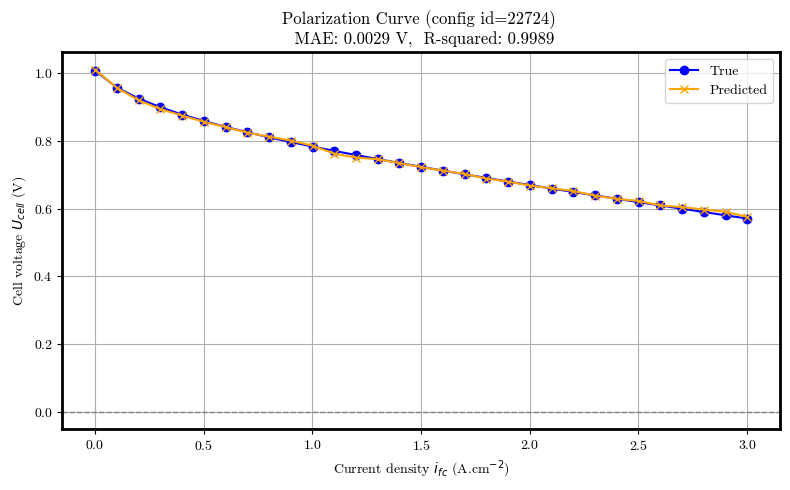

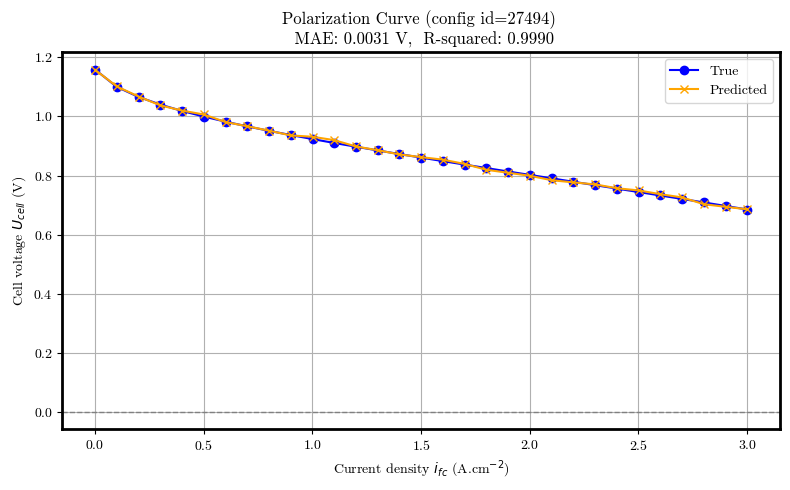

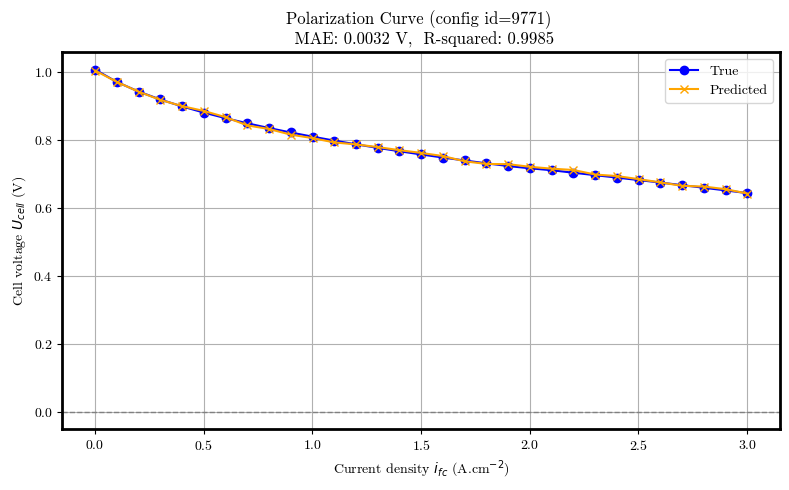

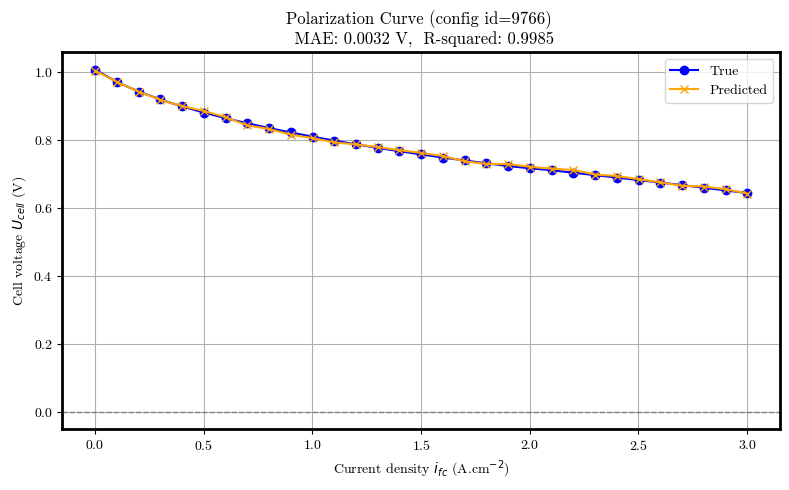

In [70]:
for id in ls_best_ids:
    plot_true_vs_predicted(original_df.loc[id])

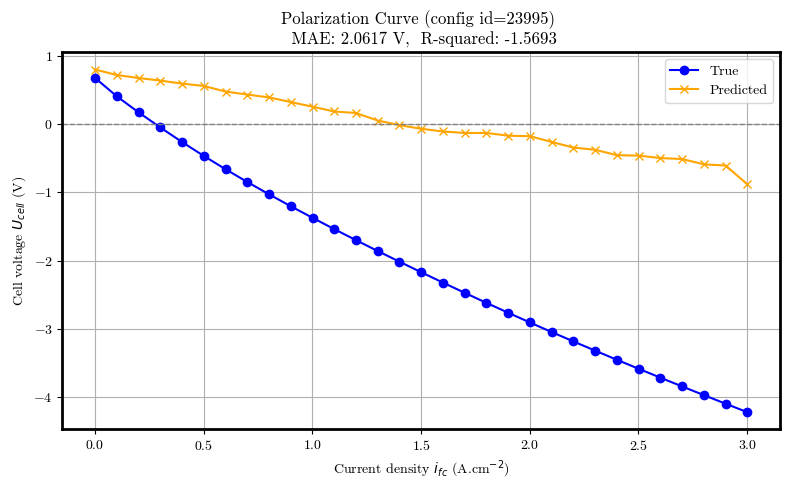

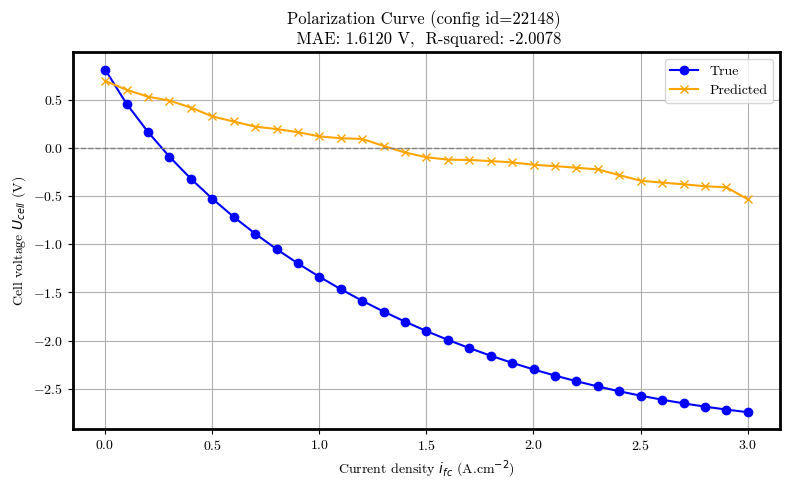

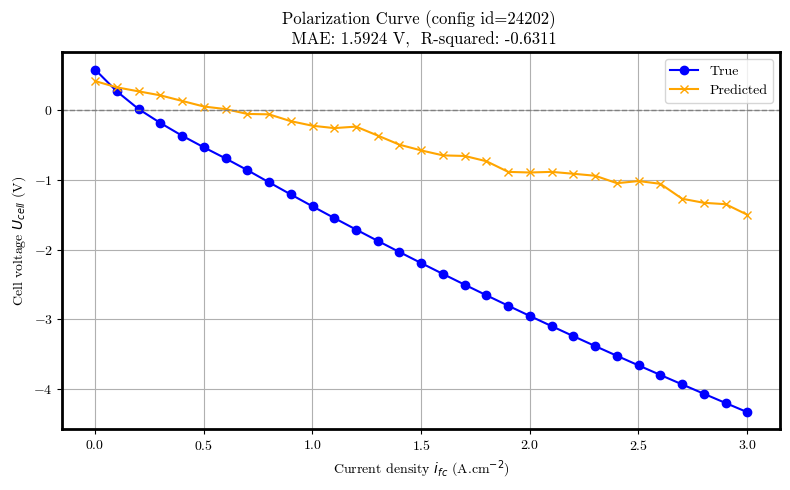

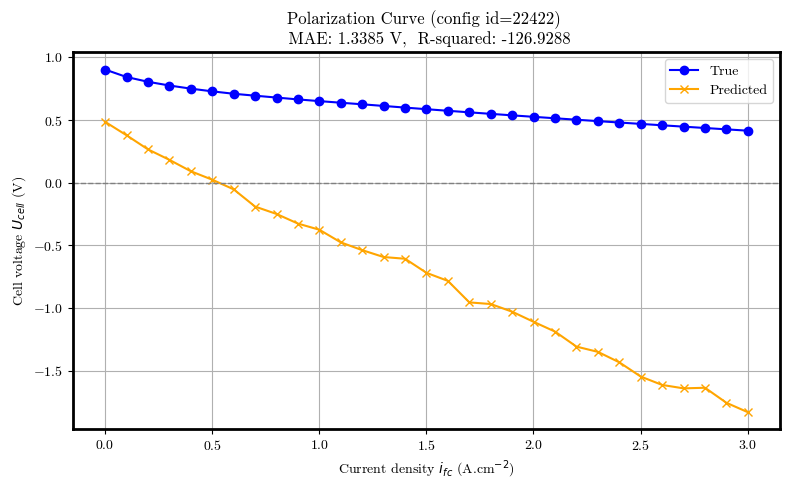

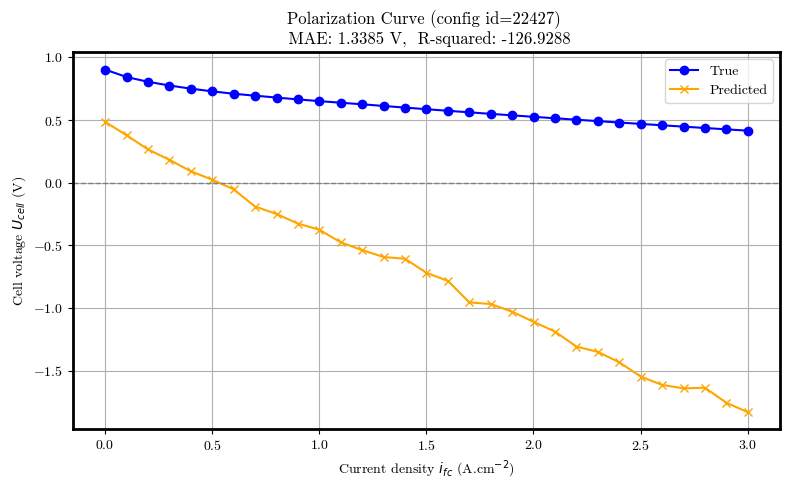

In [71]:
for id in ls_worst_ids:
    plot_true_vs_predicted(original_df.loc[id])

### Error as a function of current density

To analyze how prediction quality varies across the polarization curve, we compute the mean absolute error (MAE) and standard deviation of the prediction error for each current density value.

This diagnostic helps detect whether the surrogate struggles more at high current densities, which could be common due to nonlinearity and sharp drops in voltage in this area.

The shaded region represents ±1 standard deviation around the mean error.

C:\Users\User\AppData\Local\Temp\ipykernel_18768\548804221.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


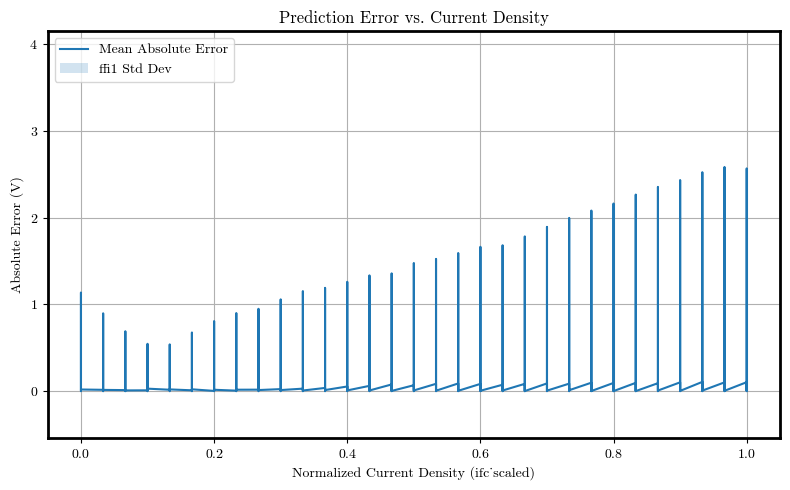

In [78]:
# Compute absolute error for each point
long_data["abs_error"] = np.abs(long_data["ucell"] - long_data["y_pred"])

# Aggregate by current density (mean + std)
error_by_ifc = (
    long_data.groupby("ifc_scaled")["abs_error"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# Plot
plt.figure(figsize=(8, 5))
sns.lineplot(data=error_by_ifc, x="ifc_scaled", y="mean", label="Mean Absolute Error")
plt.fill_between(
    error_by_ifc["ifc_scaled"],
    error_by_ifc["mean"] - error_by_ifc["std"],
    error_by_ifc["mean"] + error_by_ifc["std"],
    alpha=0.2,
    label="±1 Std Dev"
)
plt.xlabel("Normalized Current Density (ifc_scaled)")
plt.ylabel("Absolute Error (V)")
plt.title("Prediction Error vs. Current Density")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Global Feature Importance via SHAP Values

To assess which input parameters most influence the surrogate's voltage predictions, we compute SHAP values using TreeSHAP (optimized for XGBoost).

Each SHAP value quantifies how much a feature pushes the prediction up or down for a given sample. By averaging the absolute SHAP values across all samples, we get a global ranking of feature importance.

This method is model-aware and captures both:
- Direct feature effects
- Interaction effects (if present in the model)

The bar plot below shows the ranking, helping us identify the most influential features for possible dimensionality reduction or further analysis.


In [ ]:
# Load model 
# model_best_hp = joblib.load("model_best_hp.pkl")

In [83]:
# SHAP explainer for tree models
explainer = shap.Explainer(final_model)

# Compute SHAP values
print("Computing SHAP values...")
shap_values = explainer(X)

# Calculate mean absolute SHAP value per feature
mean_abs_shap = pd.DataFrame({
    'feature': X.columns,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='mean_abs_shap', ascending=False)

# Display ranking
print("\nFeature Importance Ranking (by mean |SHAP|):")
print(mean_abs_shap)

Computing SHAP values...


KeyboardInterrupt: 

In [ ]:
# Optional: bar plot
plt.figure(figsize=(8, 5))
plt.barh(mean_abs_shap["feature"], mean_abs_shap["mean_abs_shap"])
plt.xlabel("Mean(|SHAP value|)")
plt.title("SHAP Feature Importance Ranking")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### SHAP Beeswarm Summary Plot

The SHAP beeswarm plot visualizes **how each feature influences the model’s predictions** across all samples.

#### Key Elements:

- Each dot represents one sample (configuration at a given current density).
- X-axis (SHAP value) shows the impact of the feature on the predicted voltage.
  - Negative SHAP → pushes prediction lower
  - Positive SHAP → pushes prediction higher
- Color represents the actual feature value:
  - Red = high value of the feature
  - Blue = low value

#### How to Read It:

- Feature importance: Top-to-bottom ordering shows which features matter most globally.
- Effect direction: Does increasing this feature increase or decrease predicted voltage?
- Spread: Wide horizontal spread means that the feature affects different samples differently.

#### Detecting Linear vs. Nonlinear Effects:

- Linear effect: If red dots are all on one side and blue dots on the other, it's likely linear.  
  > e.g., Red (high `Pa_des`) always → lower voltage.
  
- Nonlinear effect: If red and blue dots are **scattered across both sides**, the effect depends on context — this suggests interactions or nonlinear effects.



In [ ]:
shap.summary_plot(shap_values.values, X, feature_names=X.columns)